# GEV Fitting — Extreme Sea Level Analysis

Fit a **Generalised Extreme Value (GEV)** distribution to the annual block-maxima
of the tide-gauge observations (`tg_obs_m`) for all 6 stations.

The GEV CDF is:
$$F(x) = \exp\!\left\{-\left[1 + \xi\,\frac{x-\mu}{\sigma}\right]^{-1/\xi}\right\}$$

where $\mu$ = location, $\sigma$ = scale, $\xi$ = shape.

- $\xi > 0$  →  Fréchet (heavy right tail)
- $\xi = 0$  →  Gumbel
- $\xi < 0$  →  Weibull (bounded upper tail)

We examine how $\xi$ changes across stations and whether the upper tail is bounded.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

DATA_DIR = Path("/Users/nicolocaron/Desktop/MASTER PROJECT/data/per_station")
parquets = sorted(DATA_DIR.glob("*.parquet"))
print(f"{len(parquets)} station files found")
for p in parquets:
    print(f"  • {p.name}")

6 station files found
  • station_26473_Sonderborg.parquet
  • station_28366_Assens.parquet
  • station_28548_Bagenkop.parquet
  • station_30336_Kobenhavn.parquet
  • station_30478_Koge.parquet
  • station_31616_Gedser.parquet


## 1 — Load all stations & extract annual block-maxima

In [2]:
station_data: dict[str, pd.DataFrame] = {}
annual_max: dict[str, pd.Series] = {}

for pf in parquets:
    df = pd.read_parquet(pf)
    name = df["station_name"].iloc[0]
    sid  = str(df["station_id"].iloc[0])
    label = f"{name} ({sid})"

    # Ensure datetime index
    df["time"] = pd.to_datetime(df["time"])
    df = df.set_index("time").sort_index()

    station_data[label] = df

    # Annual block maxima
    am = df["tg_obs_m"].dropna().resample("YE").max().dropna()
    annual_max[label] = am
    print(f"{label}: {len(am)} annual maxima  "
          f"(range {am.min():.3f} – {am.max():.3f} m)")

print(f"\n{len(station_data)} stations loaded.")

Sønderborg (26473): 8 annual maxima  (range 0.930 – 1.690 m)
Assens (28366): 8 annual maxima  (range 0.890 – 1.550 m)
Bagenkop (28548): 8 annual maxima  (range 0.930 – 1.770 m)
København (30336): 8 annual maxima  (range 0.880 – 1.660 m)
Køge (30478): 8 annual maxima  (range 0.850 – 1.570 m)
Gedser (31616): 8 annual maxima  (range 0.970 – 1.650 m)

6 stations loaded.


## 2 — GEV fit for each station

We use `scipy.stats.genextreme` which parametrises the shape as $c = -\xi$.

In [3]:
gev_params: dict[str, dict] = {}

for label, am in annual_max.items():
    data = am.values
    # MLE fit
    c, loc, scale = stats.genextreme.fit(data)
    xi = -c   # standard GEV convention

    # Goodness of fit: KS test
    ks_stat, ks_p = stats.kstest(data, "genextreme", args=(c, loc, scale))

    gev_params[label] = {
        "c": c, "loc": loc, "scale": scale, "xi": xi,
        "ks_stat": ks_stat, "ks_p": ks_p, "n": len(data),
    }
    tail = "Fréchet (heavy)" if xi > 0.05 else ("Weibull (bounded)" if xi < -0.05 else "Gumbel")
    print(f"{label}:  ξ = {xi:+.4f}  μ = {loc:.4f}  σ = {scale:.4f}  "
          f"KS p = {ks_p:.3f}  →  {tail}")

Sønderborg (26473):  ξ = +0.4425  μ = 1.0653  σ = 0.1470  KS p = 0.943  →  Fréchet (heavy)
Assens (28366):  ξ = +0.4311  μ = 0.9718  σ = 0.0857  KS p = 0.978  →  Fréchet (heavy)
Bagenkop (28548):  ξ = +0.5811  μ = 1.0519  σ = 0.1675  KS p = 0.937  →  Fréchet (heavy)
København (30336):  ξ = +0.1772  μ = 1.0300  σ = 0.1712  KS p = 0.965  →  Fréchet (heavy)
Køge (30478):  ξ = +0.5462  μ = 0.9396  σ = 0.1099  KS p = 0.973  →  Fréchet (heavy)
Gedser (31616):  ξ = +0.4547  μ = 1.0787  σ = 0.1174  KS p = 0.973  →  Fréchet (heavy)


## 3 — Summary table of GEV parameters

In [4]:
summary = pd.DataFrame(gev_params).T
summary.index.name = "Station"
summary = summary[["xi", "loc", "scale", "n", "ks_stat", "ks_p"]]
summary.columns = ["ξ (shape)", "μ (location)", "σ (scale)",
                    "N (years)", "KS stat", "KS p-value"]
summary = summary.round(4)
summary

,ξ (shape),μ (location),σ (scale),N (years),KS stat,KS p-value
Station,,,,,,
Sønderborg (26473),0.4425,1.0653,0.1470,8.0,0.1711,0.9435
Assens (28366),0.4311,0.9718,0.0857,8.0,0.1525,0.9779
Bagenkop (28548),0.5811,1.0519,0.1675,8.0,0.1738,0.9368
København (30336),0.1772,1.0300,0.1712,8.0,0.1610,0.9649
Køge (30478),0.5462,0.9396,0.1099,8.0,0.1559,0.9731
Gedser (31616),0.4547,1.0787,0.1174,8.0,0.1558,0.9733


## 4 — Histogram + fitted GEV PDF for each station

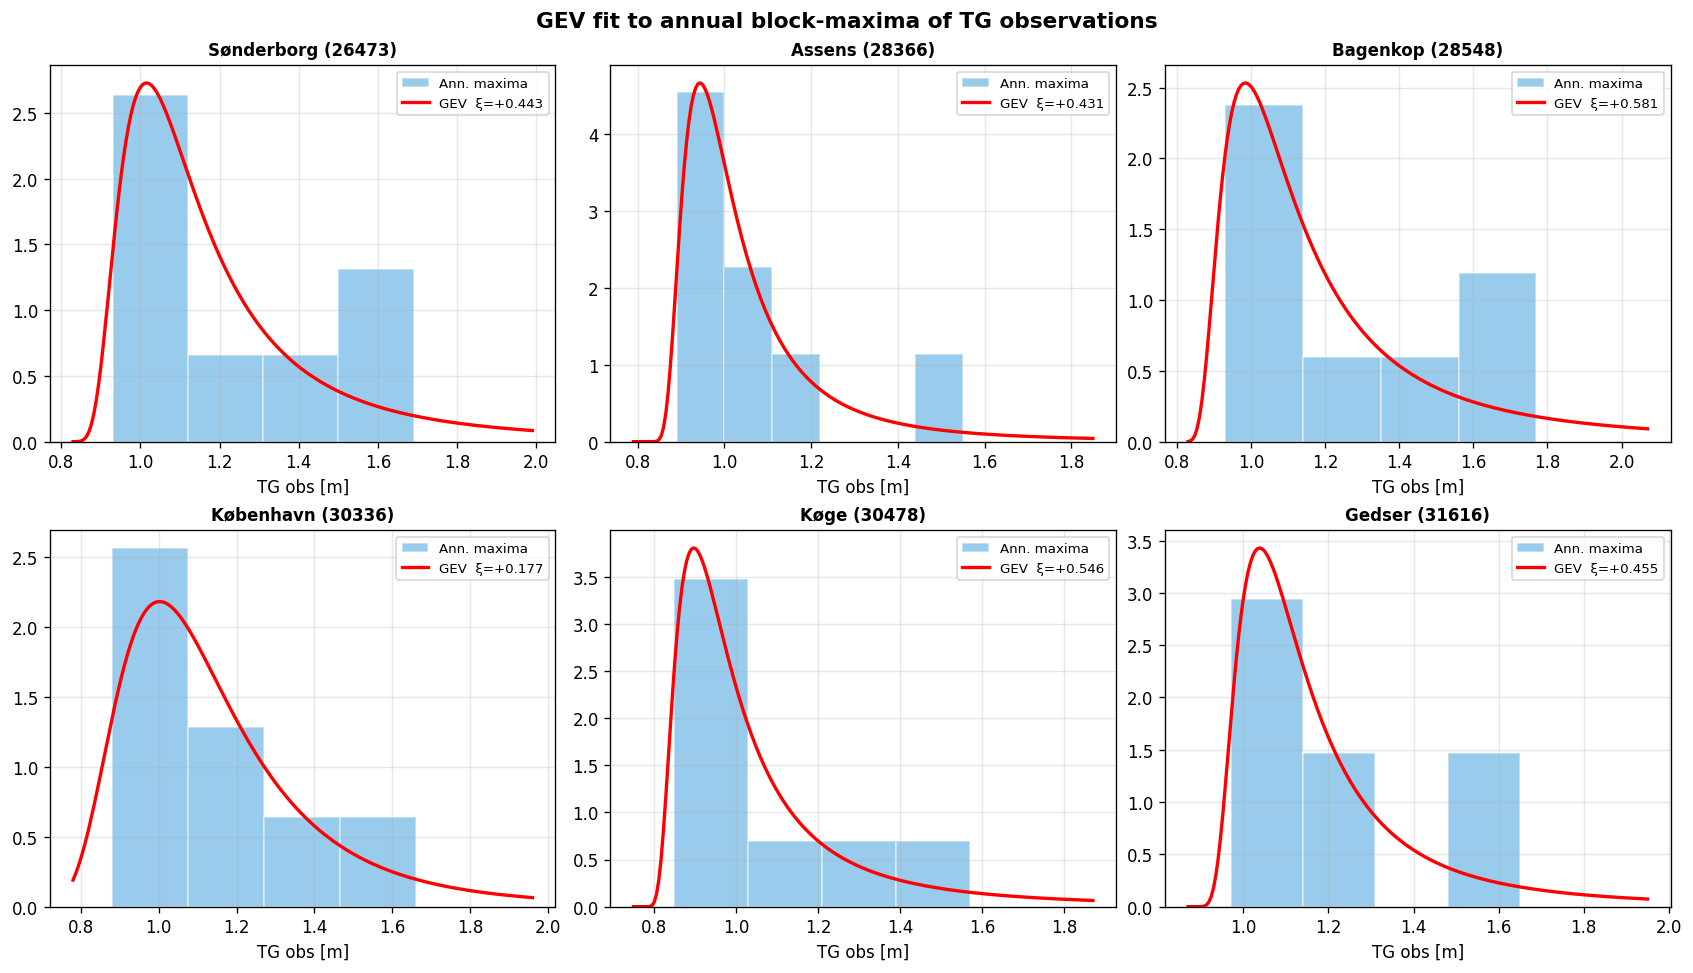

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
axes = axes.ravel()

for ax, (label, am) in zip(axes, annual_max.items()):
    data = am.values
    p = gev_params[label]
    c, loc, scale = p["c"], p["loc"], p["scale"]

    # Histogram
    ax.hist(data, bins="auto", density=True, alpha=0.5,
            color="#3498DB", edgecolor="white", label="Ann. maxima")

    # Fitted PDF
    x = np.linspace(data.min() - 0.1, data.max() + 0.3, 200)
    pdf = stats.genextreme.pdf(x, c, loc, scale)
    ax.plot(x, pdf, "r-", lw=2, label=f"GEV  ξ={p['xi']:+.3f}")

    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_xlabel("TG obs [m]")
    ax.legend(fontsize=8)

fig.suptitle("GEV fit to annual block-maxima of TG observations",
             fontsize=13, fontweight="bold")
plt.show()

## 5 — Return Level Plot (QQ against Gumbel reduced variate)

Return levels: $x_T = \mu + \frac{\sigma}{\xi}\left[(-\ln(1-1/T))^{-\xi} - 1\right]$

KeyError: 'Gedser (31616)'

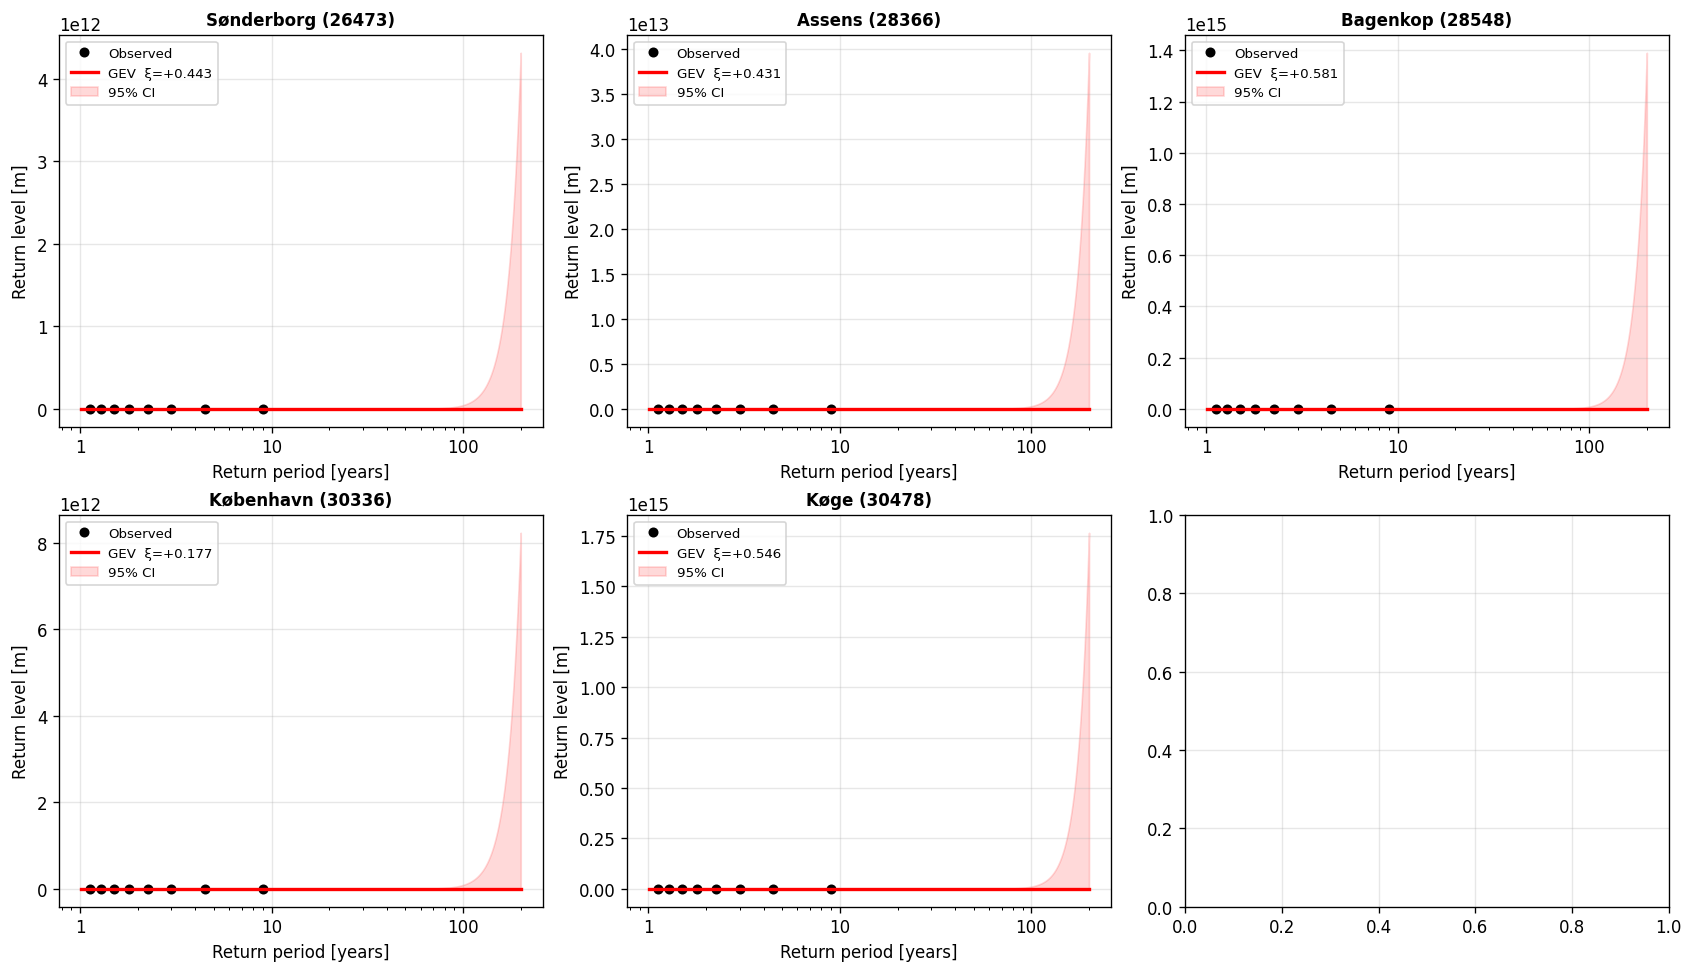

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
axes = axes.ravel()

T_range = np.logspace(np.log10(1.01), np.log10(100), 200)

for ax, (label, am) in zip(axes, annual_max.items()):
    data = np.sort(am.values)
    n = len(data)
    p = gev_params[label]
    c, loc, scale = p["c"], p["loc"], p["scale"]

    # Empirical return periods (Weibull plotting position)
    emp_prob = np.arange(1, n + 1) / (n + 1)
    emp_T = 1 / (1 - emp_prob)

    # Fitted return levels
    fitted_rl = stats.genextreme.isf(1 / T_range, c, loc, scale)

    # Clip to a reasonable range to avoid divergence with heavy-tailed fits
    y_max = data.max() * 2.5
    fitted_rl = np.clip(fitted_rl, None, y_max)

    ax.semilogx(emp_T, data, "ko", ms=5, label="Observed")
    ax.semilogx(T_range, fitted_rl, "r-", lw=2, label=f"GEV  ξ={p['xi']:+.3f}")

    # 95% CI via parametric bootstrap
    boot_rl = np.zeros((500, len(T_range)))
    for b in range(500):
        sample = stats.genextreme.rvs(c, loc, scale, size=n)
        cb, lb, sb = stats.genextreme.fit(sample)
        boot_rl[b] = np.clip(
            stats.genextreme.isf(1 / T_range, cb, lb, sb), None, y_max)
    ci_lo = np.percentile(boot_rl, 2.5, axis=0)
    ci_hi = np.percentile(boot_rl, 97.5, axis=0)
    ax.fill_between(T_range, ci_lo, ci_hi, alpha=0.15, color="red",
                    label="95% CI")

    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_xlabel("Return period [years]")
    ax.set_ylabel("Return level [m]")
    ax.legend(fontsize=8, loc="upper left")
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())

fig.suptitle("Return Level Plots — GEV annual maxima",
             fontsize=13, fontweight="bold")
plt.show()

## 6 — QQ-Plot: empirical vs fitted GEV quantiles

KeyError: 'Gedser (31616)'

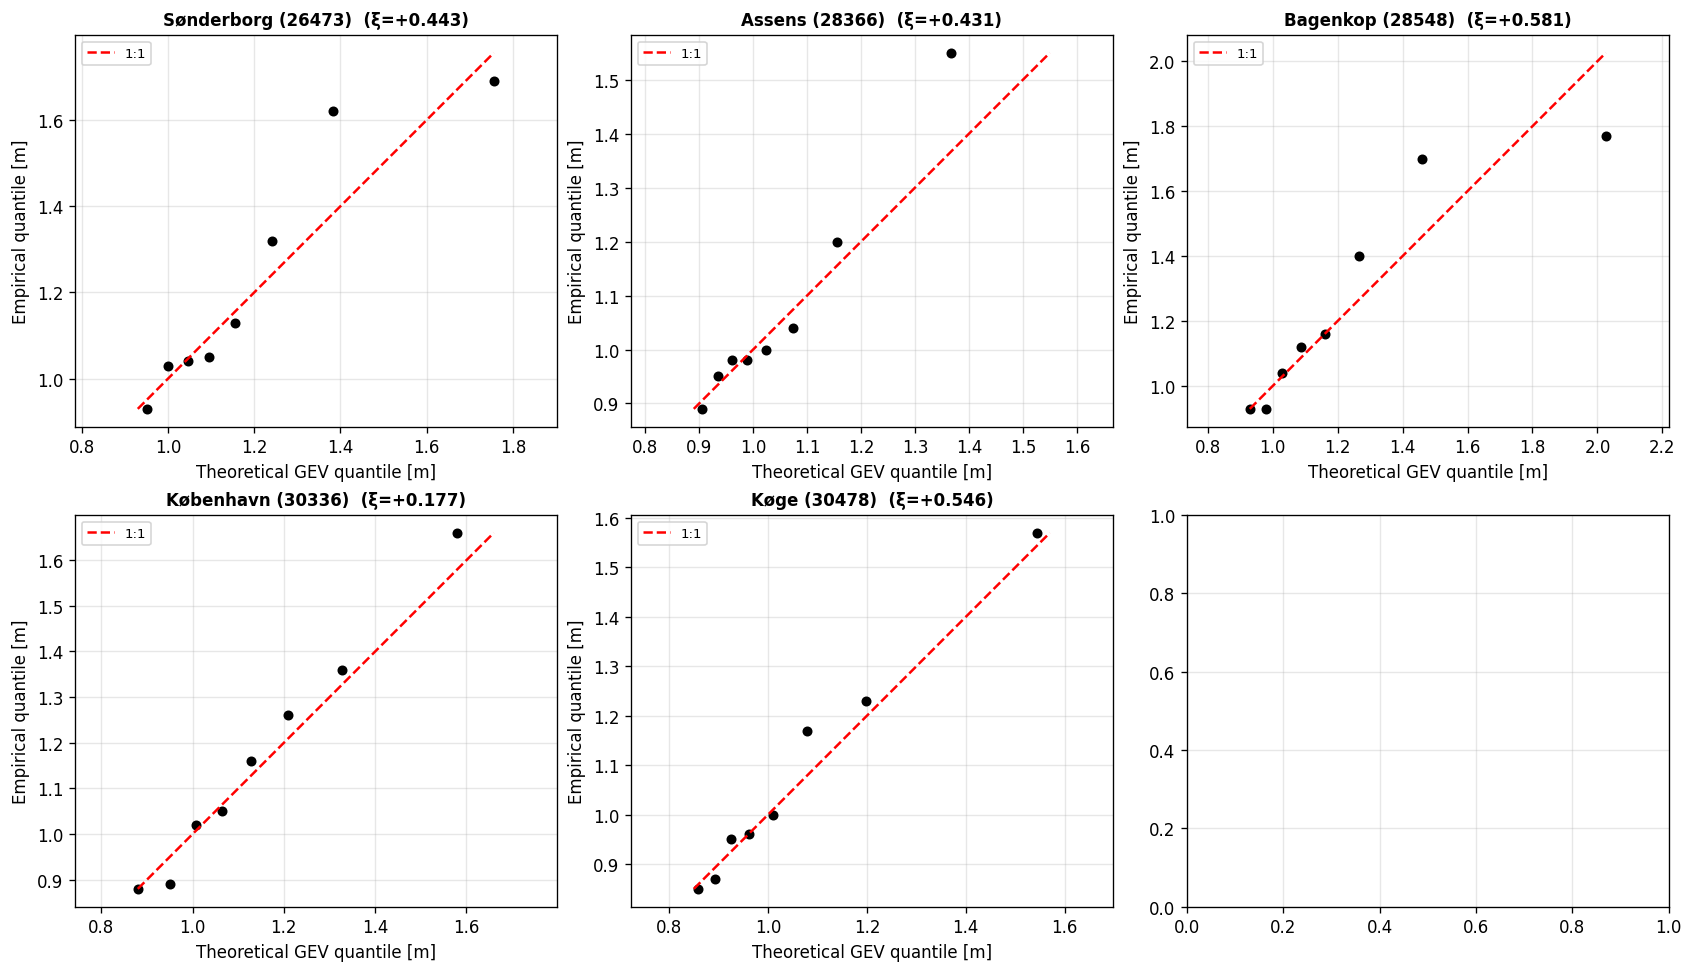

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
axes = axes.ravel()

for ax, (label, am) in zip(axes, annual_max.items()):
    data = np.sort(am.values)
    n = len(data)
    p = gev_params[label]
    c, loc, scale = p["c"], p["loc"], p["scale"]

    # Theoretical quantiles
    prob = (np.arange(1, n + 1) - 0.375) / (n + 0.25)  # Blom plotting position
    theo = stats.genextreme.ppf(prob, c, loc, scale)

    ax.plot(theo, data, "ko", ms=5)
    lims = [min(theo.min(), data.min()), max(theo.max(), data.max())]
    ax.plot(lims, lims, "r--", lw=1.5, label="1:1")

    ax.set_title(f"{label}  (ξ={p['xi']:+.3f})", fontsize=10, fontweight="bold")
    ax.set_xlabel("Theoretical GEV quantile [m]")
    ax.set_ylabel("Empirical quantile [m]")
    ax.legend(fontsize=8)
    ax.set_aspect("equal", adjustable="datalim")

fig.suptitle("QQ-Plot — GEV fit vs observed annual maxima",
             fontsize=13, fontweight="bold")
plt.show()

## 7 — Confronto dei parametri ξ tra stazioni

Visualizzazione del parametro di forma $\xi$ per capire se le code estreme
sono bounded (Weibull, $\xi < 0$) o heavy-tailed (Fréchet, $\xi > 0$).

In [1]:
labels = list(gev_params.keys())
xi_vals = [gev_params[l]["xi"] for l in labels]
short_names = [l.split(" (")[0] for l in labels]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#E74C3C" if x > 0.05 else ("#3498DB" if x < -0.05 else "#95A5A6")
          for x in xi_vals]
bars = ax.barh(short_names, xi_vals, color=colors, edgecolor="white", height=0.6)
ax.axvline(0, color="black", lw=0.8)
ax.axvline(0.05, color="grey", ls="--", lw=0.7, alpha=0.5)
ax.axvline(-0.05, color="grey", ls="--", lw=0.7, alpha=0.5)

for bar, v in zip(bars, xi_vals):
    ax.text(bar.get_width() + 0.01 * np.sign(bar.get_width()),
            bar.get_y() + bar.get_height() / 2,
            f"{v:+.3f}", va="center", fontsize=9, fontweight="bold")

ax.set_xlabel("ξ (shape parameter)")
ax.set_title("GEV shape parameter ξ across stations",
             fontsize=12, fontweight="bold")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#E74C3C", label="Fréchet (ξ > 0, heavy tail)"),
    Patch(facecolor="#95A5A6", label="≈ Gumbel (|ξ| < 0.05)"),
    Patch(facecolor="#3498DB", label="Weibull (ξ < 0, bounded)"),
]
ax.legend(handles=legend_elements, fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

NameError: name 'gev_params' is not defined

## 8 — Profile-likelihood confidence interval for ξ

Bootstrap-based 95% CI per il parametro di forma, per valutare
se $\xi$ è significativamente diverso da zero.

In [ ]:
n_boot = 1000
xi_ci = {}

for label, am in annual_max.items():
    data = am.values
    n = len(data)
    xi_boot = np.zeros(n_boot)
    for b in range(n_boot):
        sample = np.random.choice(data, size=n, replace=True)
        c_b, _, _ = stats.genextreme.fit(sample)
        xi_boot[b] = -c_b
    lo, hi = np.percentile(xi_boot, [2.5, 97.5])
    xi_ci[label] = (lo, hi)
    contains_zero = "✓ contains 0" if lo <= 0 <= hi else "✗ does NOT contain 0"
    print(f"{label}:  ξ = {gev_params[label]['xi']:+.4f}  "
          f"95% CI = [{lo:+.4f}, {hi:+.4f}]  {contains_zero}")

In [ ]:
# Forest plot of ξ with CI
fig, ax = plt.subplots(figsize=(7, 4))

for i, label in enumerate(labels):
    xi = gev_params[label]["xi"]
    lo, hi = xi_ci[label]
    color = "#E74C3C" if xi > 0.05 else ("#3498DB" if xi < -0.05 else "#95A5A6")
    ax.errorbar(xi, i, xerr=[[xi - lo], [hi - xi]],
                fmt="o", color=color, ms=7, capsize=4, capthick=1.5, lw=1.5)

ax.axvline(0, color="black", lw=0.8, ls="-")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(short_names)
ax.set_xlabel("ξ (shape parameter)")
ax.set_title("GEV shape ξ — bootstrap 95% CI", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()